In [4]:
#sales performance analysis

In [5]:
##Business problem
# the objective of this project is to analyze sales data to identify key revenue drivers, evaluate performance across different regions,brands , and categories and provide actionable insights to improve overall business performance. 

In [6]:
##Goals
# -Identify top performing brands,categories and regions.
# - Analyze revenue tends over time
# -Detect underperforming areas
# -Provide data driven business recommendations

In [7]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In [8]:
df=pd.read_csv("C:/Users/DELL/Downloads/archive (2)/global_sports_footwear_sales_2018_2026.csv")

In [9]:
df.head()

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.70,1,137.7,Card,Retail Store,Germany,Low,4.6
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.00,3,228.0,Card,Online,USA,Low,3.9
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,149.60,4,598.4,Cash,Retail Store,India,Medium,3.0
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,51.85,2,103.7,Card,Retail Store,India,High,3.4
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,80.00,4,320.0,Cash,Online,USA,Medium,3.0


In [10]:
df.shape

(30000, 18)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               30000 non-null  str    
 1   order_date             30000 non-null  str    
 2   brand                  30000 non-null  str    
 3   model_name             30000 non-null  str    
 4   category               30000 non-null  str    
 5   gender                 30000 non-null  str    
 6   size                   30000 non-null  int64  
 7   color                  30000 non-null  str    
 8   base_price_usd         30000 non-null  int64  
 9   discount_percent       30000 non-null  int64  
 10  final_price_usd        30000 non-null  float64
 11  units_sold             30000 non-null  int64  
 12  revenue_usd            30000 non-null  float64
 13  payment_method         30000 non-null  str    
 14  sales_channel          30000 non-null  str    
 15  country      

In [12]:
df.isnull().sum()

order_id                 0
order_date               0
brand                    0
model_name               0
category                 0
gender                   0
size                     0
color                    0
base_price_usd           0
discount_percent         0
final_price_usd          0
units_sold               0
revenue_usd              0
payment_method           0
sales_channel            0
country                  0
customer_income_level    0
customer_rating          0
dtype: int64

In [13]:
df['order_date']=pd.to_datetime(df['order_date'])

In [14]:
df['year']=df['order_date'].dt.year
df['month']=df['order_date'].dt.month    

In [15]:
# Total revenue 
total_revenue = df['revenue_usd'].sum()
print("Total Revenue:",total_revenue)

Total Revenue: 9081448.45


In [16]:
# Total units sold
total_units=df['units_sold'].sum()
print("Total Units Sold:",total_units)

Total Units Sold: 75006


In [17]:
# average order value
average_order_value = df['revenue_usd'].mean()
print("Average Order Value:", average_order_value)

Average Order Value: 302.7149483333333


<!- KPI Insights
-The total revenue generated is Total Revenue: 9081448.45,indicating overall business scale.

-The total of 75006 are sold, showcasing the customer demand.

-Average order value is, Average Order Value:302.7149483333333,suggesting the average spending per unit
 -->

In [18]:
# revenue by brand 
brand_revenue=df.groupby('brand')['revenue_usd'].sum().reset_index()
brand_revenue.sort_values(by='revenue_usd',ascending=False)

,brand,revenue_usd
0,ASICS,1561462.50
3,Nike,1524582.10
2,New Balance,1511401.50
4,Puma,1499094.90
5,Reebok,1498640.90
1,Adidas,1486266.55


In [19]:
##Brand-wise insights
###-Brand ASICS generates the highest revenue,indicating strong market demand and brand preference.
### -Brand Adidas shows the lower performance,which may indicate weaker positioning or lower visibility.
### -The comapny should focus on promoting top-performing branda while improving strategies for underperforming ones.


In [20]:
# Revenue by Country
Country_revenue=df.groupby('country')['revenue_usd'].sum().reset_index()
Country_revenue.sort_values(by='revenue_usd',ascending=False)

,country,revenue_usd
3,UAE,1546442.55
4,UK,1532300.05
1,India,1520898.95
5,USA,1511747.45
0,Germany,1503894.85
2,Pakistan,1466164.60


In [21]:
# region wise insights 
### -Country UAE contributes the highest revenue,making it a key market.
### -Country Pakistan shows the low sales,indicating potential growth opportunities.
### -Expending marketing efforts in underperfoming region could increse overall revenue.

In [22]:
# Revenue by category
category_revenue = df.groupby('category')['revenue_usd'].sum().reset_index()
category_revenue.sort_values(by='revenue_usd', ascending=False)

,category,revenue_usd
2,Lifestyle,1844628.75
4,Training,1836338.65
0,Basketball,1822369.65
3,Running,1805450.70
1,Gym,1772660.70


In [23]:
# category insight
###-category Lifestyle is top performing segment,contibuting the most to revenue.
###-category Gym underperforms,suggesting low demand or ineffective sales strategies.
###-The Business can focus on optimizing product offering in weaker categories.  

In [24]:
# Revenue by sales channel
channel_revenue = df.groupby('sales_channel')['revenue_usd'].sum().reset_index()
channel_revenue

,sales_channel,revenue_usd
0,Online,4540629.20
1,Retail Store,4540819.25


In [25]:
# Monthly revenue trend
monthly_revenue = df.groupby(['year','month'])['revenue_usd'].sum().reset_index()
monthly_revenue.head()

,year,month,revenue_usd
0,2018,1,92227.90
1,2018,2,78824.55
2,2018,3,89647.00
3,2018,4,75758.10
4,2018,5,87102.30


In [26]:
#Time based insights
### -sales show a fluctuating trend over time rather than a consistant increase or decrease.
###-revenue dropped in february after a strong january,then recovered in march.
###- the absence of steady growth suggests the need forstrategies to stabilize across months

In [27]:
df.to_csv("cleaned_footwear_sales.csv", index=False)

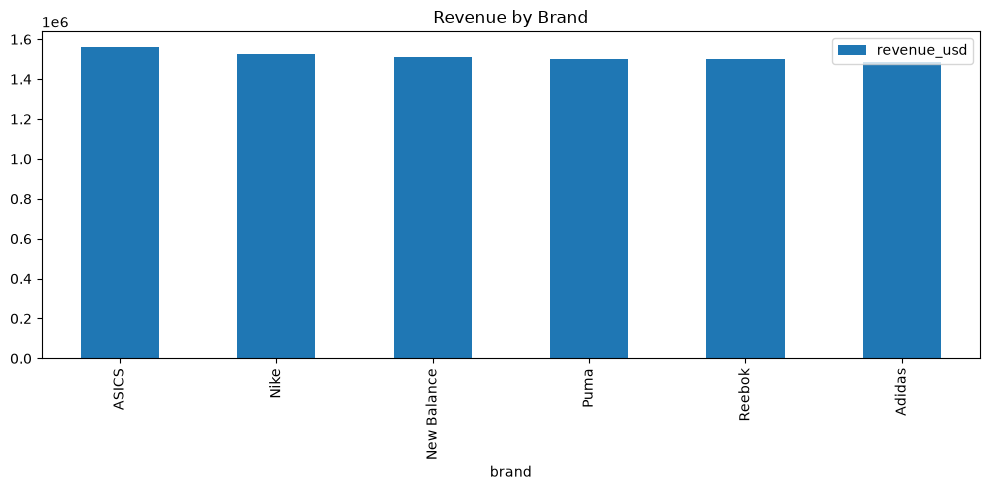

In [28]:
# Example: Bar chart for brand revenue
brand_revenue.sort_values('revenue_usd', ascending=False).plot(
    kind='bar', x='brand', y='revenue_usd', title='Revenue by Brand', figsize=(10,5)
)
plt.tight_layout()
plt.show()

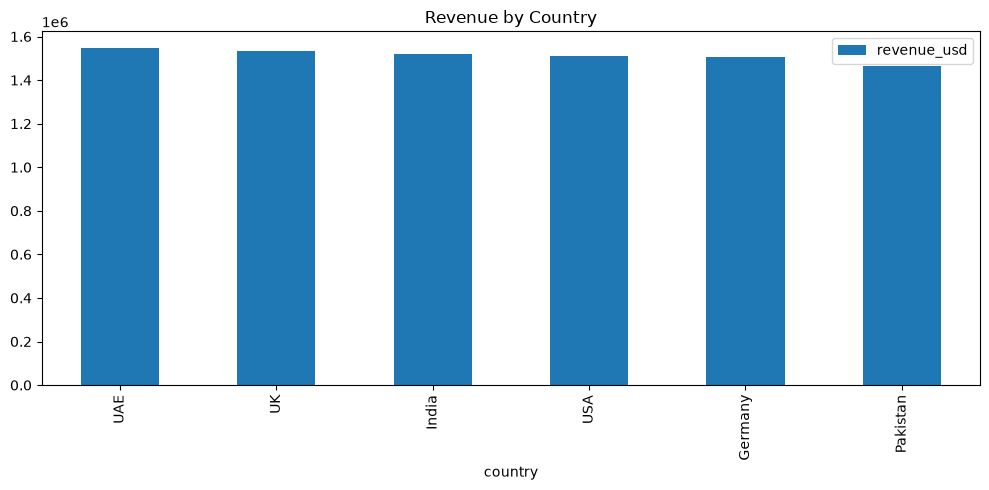

In [31]:
Country_revenue.sort_values('revenue_usd', ascending=False).plot(
    kind='bar', x='country', y='revenue_usd', title='Revenue by Country', figsize=(10,5)
)
plt.tight_layout()
plt.show()


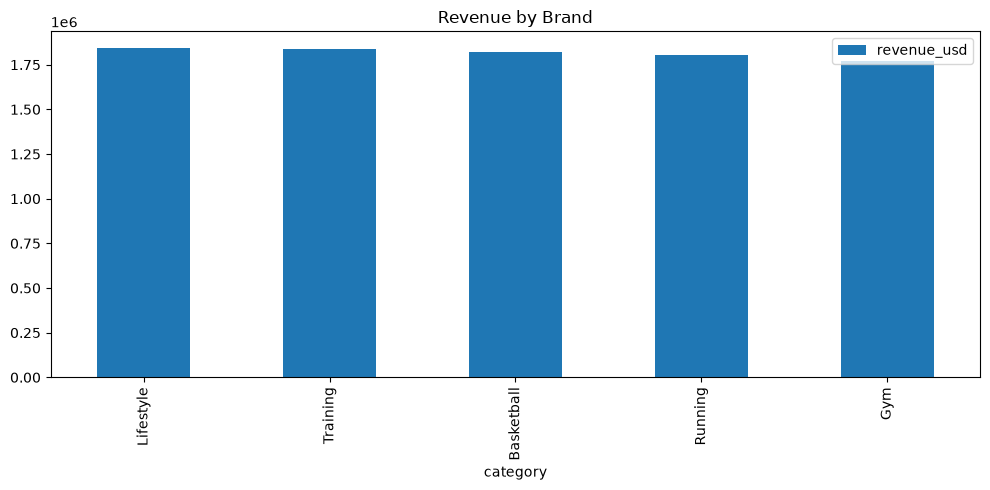

In [32]:
category_revenue.sort_values('revenue_usd', ascending=False).plot(
    kind='bar', x='category', y='revenue_usd', title='Revenue by Brand', figsize=(10,5)
)
plt.tight_layout()
plt.show()

<Axes: xlabel='month'>

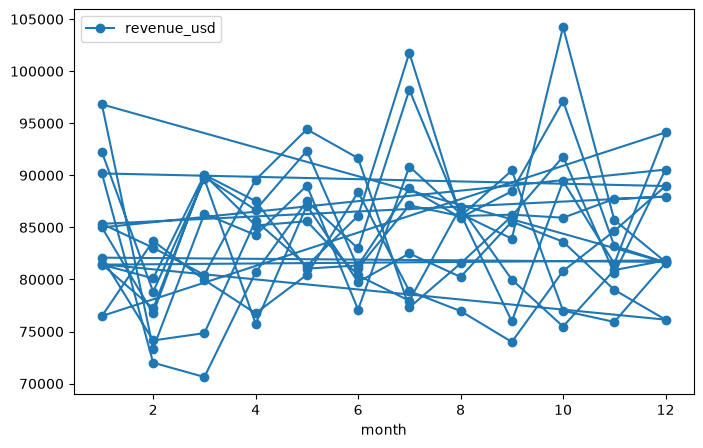

In [36]:
monthly_revenue.plot(
    x='month',
    y='revenue_usd',
    kind='line',
    marker='o',
    figsize=(8,5)

)